# Notebook 06 — Publication Figures

Generates all publication-quality figures for the BMC Bioinformatics paper.

## Figures produced

| Figure | Description |
|--------|-------------|
| Fig 1  | Conceptual diagram: TCR formula and definitional leakage path |
| Fig 2  | Clean vs leaky AUROC comparison (main result) |
| Fig 3  | AUC Inflation Index heatmap by leakage type × model |
| Fig 4  | Scenario sensitivity: clean AUROC across 4 scenarios |
| Fig 5  | Seed robustness sweep (100 seeds) |
| Fig 6  | SHAP feature importance: clean vs leaky pipelines |
| Fig S1 | Variable distribution plots |
| Fig S2 | Calibration curves |
| Fig S3 | PR-AUC and Brier score by leakage type |


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Ensure output directories exist
Path('../results/figures').mkdir(parents=True, exist_ok=True)

# Global aesthetics
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
})

COLORS = {
    'clean':        '#2196F3',
    'definitional': '#F44336',
    'outcome':      '#9C27B0',
    'preprocessing':'#FF9800',
    'resampling':   '#4CAF50',
    'label':        '#795548',
    'feature_sel':  '#607D8B',
    'calibration':  '#E91E63',
}

print("Setup complete")

Setup complete


## Fig 1 — Conceptual diagram: TCR formula and definitional leakage

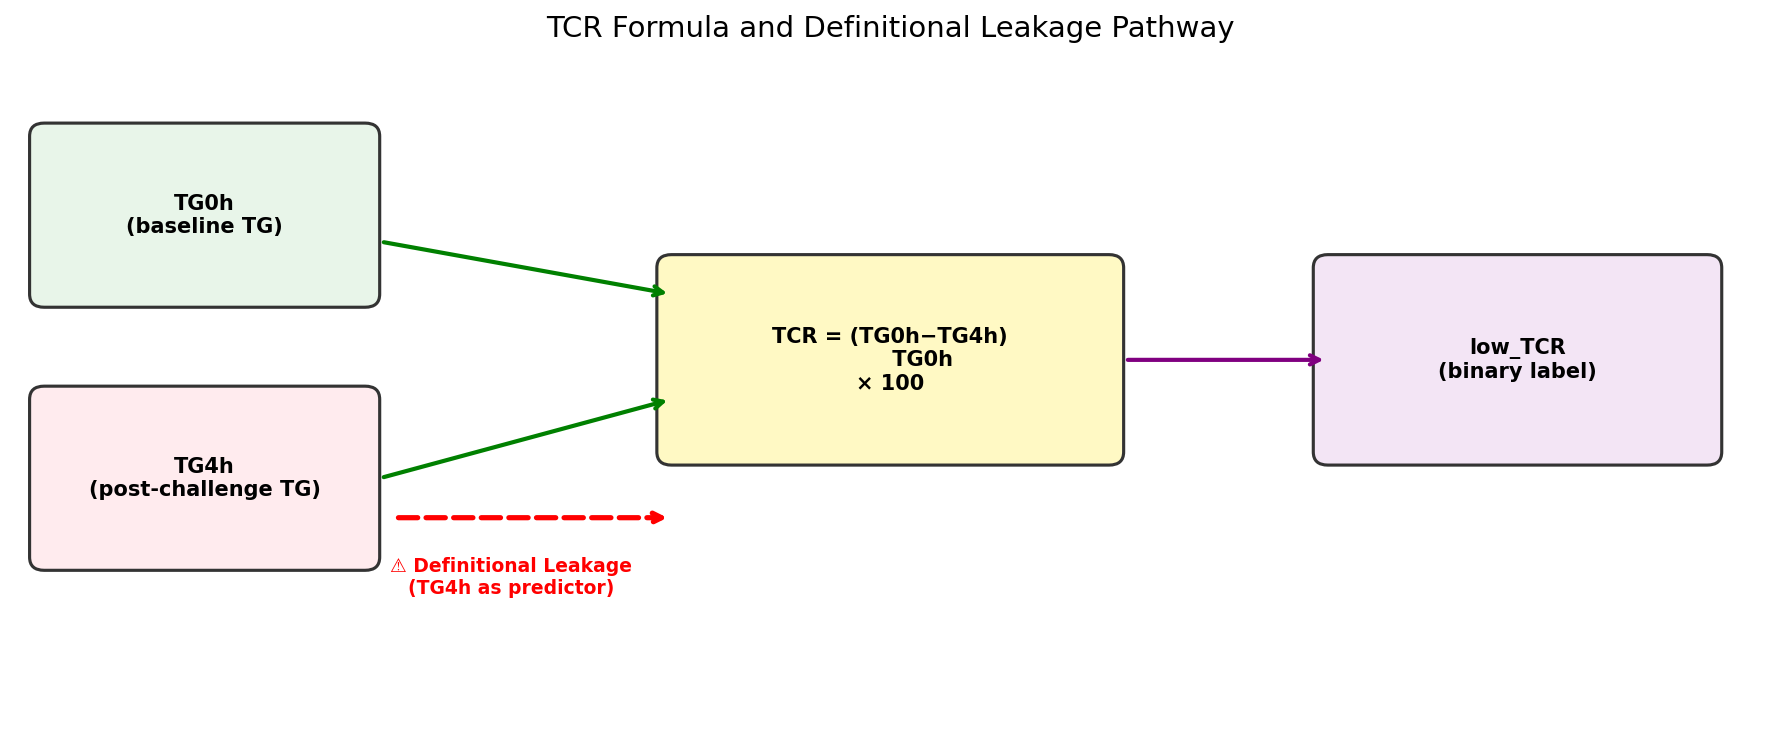

Fig 1 saved


In [2]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis('off')

# Boxes
def box(ax, x, y, w, h, text, color='#E3F2FD', fontsize=10):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                    facecolor=color, edgecolor='#333', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold')

box(ax, 0.2, 3.2, 2.2, 1.2, 'TG0h\n(baseline TG)', color='#E8F5E9')
box(ax, 0.2, 1.2, 2.2, 1.2, 'TG4h\n(post-challenge TG)', color='#FFEBEE')
box(ax, 4.5, 2.0, 3.0, 1.4, 'TCR = (TG0h−TG4h)\n         TG0h\n× 100', color='#FFF9C4')
box(ax, 9.0, 2.0, 2.6, 1.4, 'low_TCR\n(binary label)', color='#F3E5F5')

# Arrows
ax.annotate('', xy=(4.5, 3.2), xytext=(2.5, 3.6),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.annotate('', xy=(4.5, 2.4), xytext=(2.5, 1.8),
            arrowprops=dict(arrowstyle='->', color='green', lw=2))
ax.annotate('', xy=(9.0, 2.7), xytext=(7.6, 2.7),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2))

# Leakage arrow (TG4h -> model, bypassing TCR)
ax.annotate('', xy=(4.5, 1.5), xytext=(2.6, 1.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5, linestyle='dashed'))
ax.text(3.4, 1.05, '⚠ Definitional Leakage\n(TG4h as predictor)',
        ha='center', va='center', fontsize=9, color='red', fontweight='bold')

ax.set_title('TCR Formula and Definitional Leakage Pathway', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig('../results/figures/fig1_conceptual_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 saved")

## Fig 2 — Clean vs Leaky AUROC (main result)

In [3]:
# Load pre-computed results
import pandas as pd, numpy as np
clean_df   = pd.read_csv('../results/tables/clean_results.csv',
                         keep_default_na=False, na_values=['NA','NaN','nan',''])
leakage_df = pd.read_csv('../results/tables/leakage_benchmark.csv',
                         keep_default_na=False, na_values=['NA','NaN','nan',''])
print('clean_results shape:', clean_df.shape)
print('leakage_benchmark shape:', leakage_df.shape)
print(leakage_df[['model','pipeline','AUROC_mean','AUC_inflation']].to_string(index=False))


clean_results shape: (4, 8)
leakage_benchmark shape: (36, 8)
             model                  pipeline  AUROC_mean  AUC_inflation
LogisticRegression                     clean      0.5090         0.0000
LogisticRegression              tg4h_leakage      0.9995         0.4905
LogisticRegression               tcr_leakage      0.9997         0.4907
LogisticRegression            global_scaling      0.5150         0.0060
LogisticRegression      global_winsorization      0.5163         0.0073
LogisticRegression    global_label_threshold      0.5150         0.0060
LogisticRegression           smote_before_cv      0.5455         0.0365
LogisticRegression feature_selection_leakage      0.5138         0.0048
LogisticRegression          combined_leakage      0.9996         0.4906
      RandomForest                     clean      0.4934         0.0000
      RandomForest              tg4h_leakage      0.9872         0.4938
      RandomForest               tcr_leakage      1.0000         0.5066
   

## Generate all other figures via plotting.py

In [4]:
# Generate all figures via main() in plotting.py
import sys, os
os.chdir('..')  # run from project root so paths resolve correctly
from src.plotting import main as plot_main
import sys
sys.argv = ['plotting.py']
plot_main()
os.chdir('notebooks')  # restore cwd


Figures:   0%|                                                      | 0/5 [00:00<?, ?it/s]

Plotting: Figure 1 — DAG:   0%|                                     | 0/5 [00:00<?, ?it/s]

Plotting: Figure 1 — DAG:   0%|                                     | 0/5 [00:00<?, ?it/s]

Plotting: Figure 1 — DAG:  20%|█████▊                       | 1/5 [00:00<00:00,  4.31it/s]

Plotting: Figure 2 — Cohort validation:  20%|███            | 1/5 [00:00<00:00,  4.31it/s]

...

  Saved Figure 3 -> results\figures\fig3_leakage_benchmark.png
  Saved Figure 5 -> results\figures\fig5_scenario_sensitivity.png


Plotting: Figure 6 — Calibration curves:  80%|███████████▏  | 4/5 [00:02<00:00,  2.27it/s]

Plotting: Figure 6 — Calibration curves: 100%|██████████████| 5/5 [00:02<00:00,  2.95it/s]

Plotting: Figure 6 — Calibration curves: 100%|██████████████| 5/5 [00:02<00:00,  2.25it/s]

  Saved Figure 6 -> results\figures\fig6_calibration.png

All available figures generated.


In [5]:
# List all generated figures
import os
figs = sorted(Path('../results/figures/').glob('*.png'))
print(f"Generated {len(figs)} figure files:")
for f in figs:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45} {size_kb:>7.1f} KB")

Generated 23 figure files:
  01_distributions_null.png                        95.4 KB
  03_clean_pipeline_auroc.png                      45.4 KB
  04_leakage_heatmap.png                          107.8 KB
  05_scenario_comparison.png                       53.0 KB
  05_seed_stability.png                           114.3 KB
  domain_shift_calibration.png                     52.0 KB
  fig1_conceptual_diagram.png                      56.6 KB
  fig1_dag.png                                     92.4 KB
  fig2_cohort_validation.png                      148.3 KB
  fig3_leakage_benchmark.png                       94.7 KB
  fig5_scenario_sensitivity.png                    55.3 KB
  fig6_calibration.png                             98.2 KB
  shap_beeswarm_clean.png                         162.4 KB
  shap_beeswarm_leaky.png                          99.9 KB
  shap_comparison_bars.png                         54.7 KB
  validation_corr_moderate_signal.png             125.6 KB
  validation_corr_null.png   